# PT3S
Use SIR 3S Modeldata and SIR 3S Results in pure Python.

With pandas, matplotlib and others.

For documentation, test, verification, analysis, reporting, prototyping, play.

## Install Python
Anaconda3-5.2.0-Windows-x86_64.exe:

Python 3.6.5 |Anaconda, Inc.| (default, Mar 29 2018, 13:32:41) [MSC v.1900 64 bit (AMD64)]

Microsoft Visual Studio Professional 2017 Version 15.8.4

PTVS 15.8.18241.1-15.0

## Install PT3S to site-packages

In [ ]:
!pip uninstall --yes PT3S
!pip install PT3S --no-cache-dir

## OR use local PT3S under Development

In [ ]:
!pip install -e .

## about from PT3S ... import ... and pip install -e .

In [ ]:
%pwd

In [ ]:
# works only if pip install -e .is NOT active:
from PT3S import Mx,Xm,Rm
# or if subdir is PT3S
#%cd -q ..
# ...
#%cd -q PT3S 

In [1]:
# if pip install -e .IS active
# the local modules can be imported with:
import Mx, Xm, Rm
# if %pwd is local devdir

# ggf. Tests

INFO    ; __main__.<module>: Start unittests (DocTestSuite...). testDir: testdata
.
----------------------------------------------------------------------
Ran 1 test in 3.706s

OK
.
----------------------------------------------------------------------
Ran 1 test in 21.156s

OK
.
----------------------------------------------------------------------
Ran 1 test in 4.990s

OK
INFO    ; __main__.<module>: Start doctests (DocTestFinder...). testDir: testdata


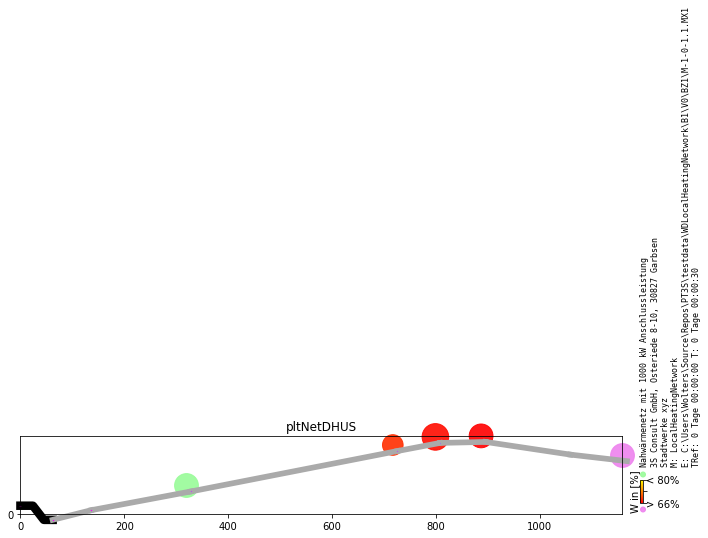

In [2]:
%run test.py --dotResolution .1

INFO    ; __main__.<module>: Start unittests (DocTestSuite...). testDir: testdata09
INFO    ; __main__.<module>: Start unittests (DocTestSuite...). testDir: testdata09
.
----------------------------------------------------------------------
Ran 1 test in 3.975s

OK
.
----------------------------------------------------------------------
Ran 1 test in 19.198s

OK
.
----------------------------------------------------------------------
Ran 1 test in 4.571s

OK
INFO    ; __main__.<module>: Start doctests (DocTestFinder...). testDir: testdata09
INFO    ; __main__.<module>: Start doctests (DocTestFinder...). testDir: testdata09


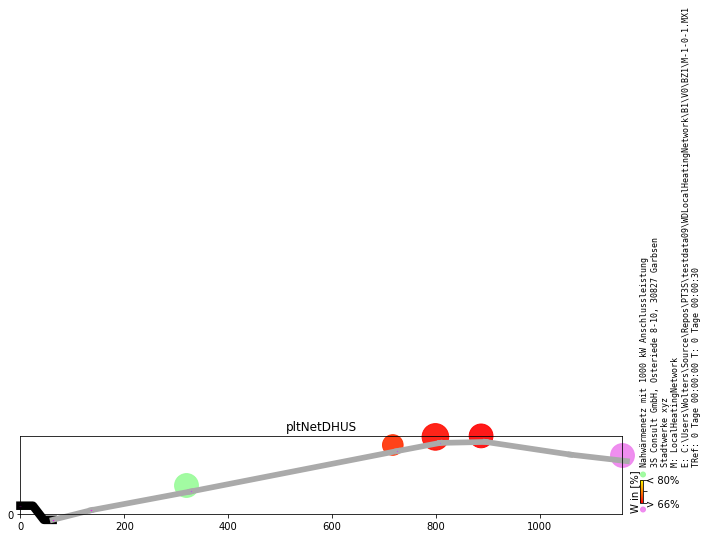

In [3]:
%run test.py --testDir testdata09

# Rm Plot Beispiele

## Vorbereitung

In [4]:
# ---
# Imports
# ---
import logging
logger = logging.getLogger('PT3S')  
import os
import pandas as pd
import matplotlib.pyplot as plt
path = os.path.dirname('.')

In [5]:
# ---
# LocalHeatingNetwork
# ---
xmlFile=os.path.join(path,'testdata\LocalHeatingNetwork.XML')
xm=Xm.Xm(xmlFile=xmlFile)
mx1File=os.path.join(path,'testdata\WDLocalHeatingNetwork\B1\V0\BZ1\M-1-0-1.1.MX1')
mx=Mx.Mx(mx1File=mx1File,NoH5Read=True,NoMxsRead=True)
mx.setResultsToMxsFile(NewH5Vec=True)
rm=Rm.Rm(xm=xm,mx=mx)

## Bsp1: Prozentdarstellung - keine Klassen

In [7]:
vNRCV_Mx1=xm.dataFrames['vNRCV_Mx1']

In [17]:
vNRCV_Mx1[vNRCV_Mx1['Sir3sID'].str.match('WBLZ~WärmeblnzGes~\S*~\S+~WES')]
vNRCV_Mx1[vNRCV_Mx1['Sir3sID'].str.match('KNOT~~~\S+~\S+')]
 #s.str.extract(r'([ab])(\d)')
df=vNRCV_Mx1['Sir3sID'].str.extract('(?P<OBJTYPE>\S+)~(?P<KI>\S*)?~(?P<KK>\S*)?~(?P<ID>\S+)~(?P<ATTRTYPE>\S+)')
    

In [21]:
df[df['KI'].str.len()==0]

,OBJTYPE,KI,KK,ID,ATTRTYPE
6,KNOT,,,5397990465339071638,QM
13,WBLZ,,,4694700216019268978,WVB


In [27]:
df=df.assign(Sir3sID=lambda df: df.OBJTYPE+'~'+df.KI+'~'+df.KK+'~'+df.ID+'~'+df.ATTRTYPE)

In [28]:
df

,OBJTYPE,KI,KK,ID,ATTRTYPE,Sir3sID
0,FWES,R3,V-1,5638756766880678918,W,FWES~R3~V-1~5638756766880678918~W
1,KNOT,R-L,,5356267303828212700,PH,KNOT~R-L~~5356267303828212700~PH
2,KNOT,R3,,5219230031772497417,T,KNOT~R3~~5219230031772497417~T
3,KNOT,V-1,,5049461676240771430,T,KNOT~V-1~~5049461676240771430~T
4,KNOT,V-K007,,5741235692335544560,DP,KNOT~V-K007~~5741235692335544560~DP
5,KNOT,V-L,,5736262931552588702,PH,KNOT~V-L~~5736262931552588702~PH
6,KNOT,,,5397990465339071638,QM,KNOT~~~5397990465339071638~QM
7,PUMP,R-1,R2,5481331875203087055,N,PUMP~R-1~R2~5481331875203087055~N
8,VENT,V-1,V-L,4678923650983295610,QM,VENT~V-1~V-L~4678923650983295610~QM
9,WBLZ,WärmeblnzGes,,5262603207038486299,WES,WBLZ~WärmeblnzGes~~5262603207038486299~WES


In [33]:
pd.merge(vNRCV_Mx1, df, how='inner', on='Sir3sID',  suffixes=('', '_y'))['Sir3sID']

0                FWES~R3~V-1~5638756766880678918~W
1                 KNOT~R-L~~5356267303828212700~PH
2                   KNOT~R3~~5219230031772497417~T
3                  KNOT~V-1~~5049461676240771430~T
4              KNOT~V-K007~~5741235692335544560~DP
5                 KNOT~V-L~~5736262931552588702~PH
6                    KNOT~~~5397990465339071638~QM
7                PUMP~R-1~R2~5481331875203087055~N
8              VENT~V-1~V-L~4678923650983295610~QM
9       WBLZ~WärmeblnzGes~~5262603207038486299~WES
10    WBLZ~WärmeblnzGes~~5262603207038486299~WSPEI
11      WBLZ~WärmeblnzGes~~5262603207038486299~WVB
12    WBLZ~WärmeblnzGes~~5262603207038486299~WVERL
13                  WBLZ~~~4694700216019268978~WVB
Name: Sir3sID, dtype: object

In [35]:
vKNOT=xm.dataFrames['vKNOT']
dfNrcvKNOT=pd.merge(df[df['KI'].str.len()==0],vKNOT,how='inner', left_on='ID', right_on='pk',  suffixes=('', '_z'))

In [36]:
dfNrcvKNOT=dfNrcvKNOT.assign(Sir3sIDNeu=lambda df: df.OBJTYPE+'~'+df.NAME+'~'+df.KK+'~'+df.ID+'~'+df.ATTRTYPE)

In [ ]:
dfNrcvKNOT

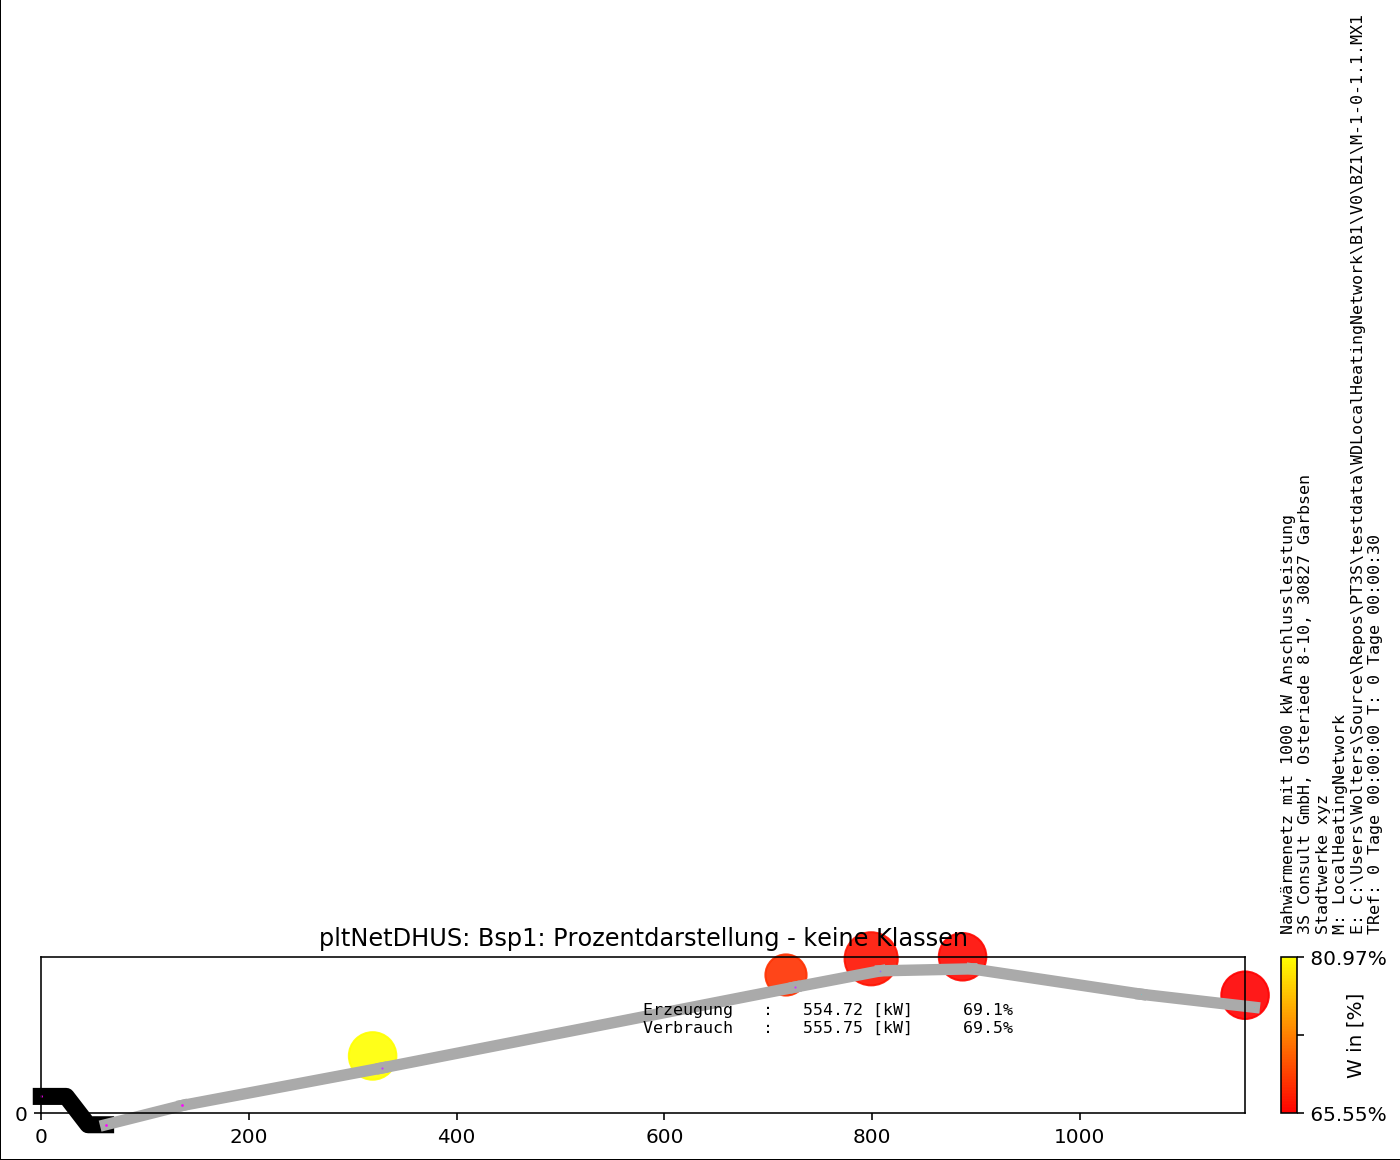

In [6]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                                  
                 pltTitle='pltNetDHUS: Bsp1: Prozentdarstellung - keine Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
                     
                   )
plt.show()

## Bsp2: Prozentdarstellung - Klassen

In [ ]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                   
                 pltTitle='pltNetDHUS: Bsp2: Prozentdarstellung - Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
    
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureCBFixedLimitHigh=0.80
                 ,pFWVBMeasureCBFixedLimitLow=0.66
                   )
plt.show()

## Bsp3: keine Prozentdarstellung - Klassen

In [ ]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(         
                 pltTitle='pltNetDHUS: Bsp3: keine Prozentdarstellung - Klassen'                   
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureInRefPerc=False  
                 ,pFWVBMeasure='FWVB~*~*~*~W' 
                 
                 ,pFWVBMeasureCBFixedLimitHigh=200.
                 ,pFWVBMeasureCBFixedLimitLow=130.
                   )
plt.show()

## Aufräumen

In [ ]:
if os.path.exists(mx.h5FileVecs):                        
    os.remove(mx.h5FileVecs)

# Deploy

python setup.py clean sdist bdist_wheel 

pip install twine

twine upload dist/*

# Develop

In [ ]:
!pip install -e .

due to ...\Lib\site-packages\PT3S.egg-link

import PT3S or from PT3S import ...

will work (if PythonShell is executed .. PT3SSourcecodeDir)

and point to _local PT3SSourcecodeDir

Repository: https://github.com/aw3s/PT3S.git